In [3]:
import os
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Đảm bảo có thể import được package src khi chạy nbconvert
ROOT_DIR = Path("..").resolve()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from src.data.cleaner import DataCleaner

sns.set(style="whitegrid")

cleaner = DataCleaner(config_path="../configs/params.yaml")

raw_df, clean_df = cleaner.run_full_cleaning(save=True)

cols = ["Quantity", "UnitPrice"]
summary_before = raw_df[cols].describe()
summary_after = clean_df[cols].describe()

print("=== Thống kê trước khi làm sạch ===")
display(summary_before)

print("\n=== Thống kê sau khi làm sạch ===")
display(summary_after)

if "is_return" in clean_df.columns:
    return_rate = clean_df["is_return"].mean()
    print(f"\nTỷ lệ giao dịch trả hàng (is_return=1): {return_rate:.2%}")


2026-03-15 15:47:01,746 - src.data.cleaner - INFO - Đã load cấu hình từ ..\configs\params.yaml
2026-03-15 15:47:01,765 - src.data.cleaner - INFO - Đang đọc dữ liệu từ D:\ki2_nam3\dữ liệu lớn\btl\BTL_DLL\data\raw\data.csv
2026-03-15 15:47:02,566 - src.data.cleaner - INFO - Đã load 541909 dòng, 8 cột
2026-03-15 15:47:02,576 - src.data.cleaner - INFO - Đang loại bỏ 135080 dòng thiếu CustomerID theo cấu hình.
2026-03-15 15:47:02,748 - src.data.cleaner - INFO - Hoàn tất xử lý missing. Còn lại 406829 dòng.
2026-03-15 15:47:02,764 - src.data.cleaner - INFO - Đang tạo cột is_return...
2026-03-15 15:47:02,858 - src.data.cleaner - INFO - Phát hiện 8905 giao dịch trả hàng (is_return=1).
2026-03-15 15:47:02,865 - src.data.cleaner - INFO - Loại bỏ 40 dòng có UnitPrice <= 0 (giá bằng 0 hoặc âm).
2026-03-15 15:47:02,992 - src.data.cleaner - INFO - Ngưỡng outlier Quantity: [1.00, 120.00]; UnitPrice: [0.21, 15.00]
2026-03-15 15:47:03,016 - src.data.cleaner - INFO - Đã winsorize 4029 giá trị Quantity cự

=== Thống kê trước khi làm sạch ===


,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000



=== Thống kê sau khi làm sạch ===


,Quantity,UnitPrice
count,406789.000000,406789.000000
mean,10.862044,2.858958
std,18.122425,2.824352
min,1.000000,0.210000
25%,2.000000,1.250000
50%,5.000000,1.950000
75%,12.000000,3.750000
max,120.000000,15.000000



Tỷ lệ giao dịch trả hàng (is_return=1): 2.19%


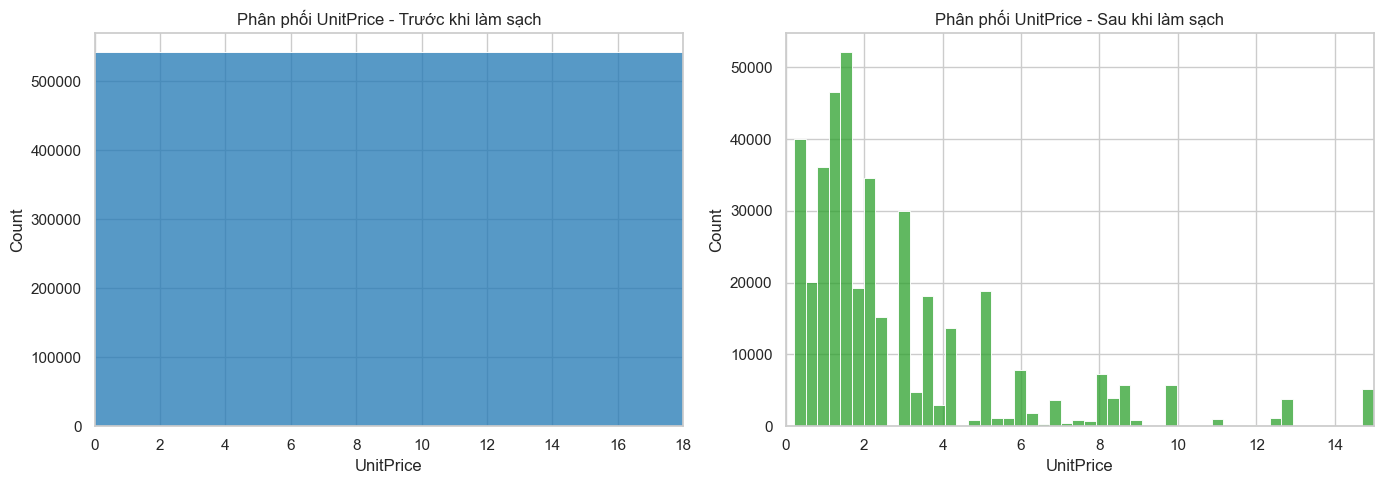

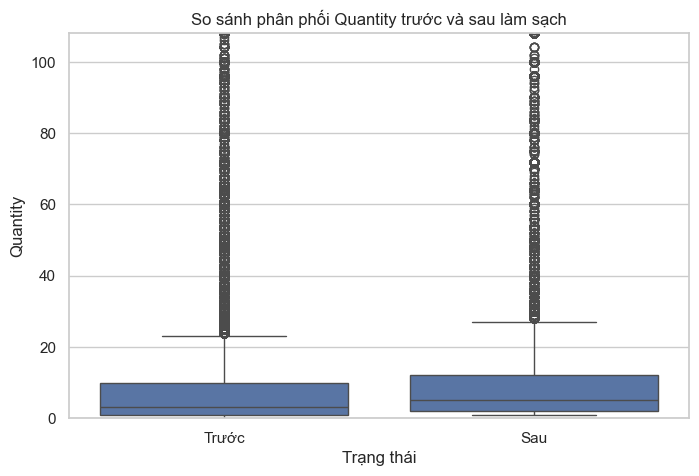

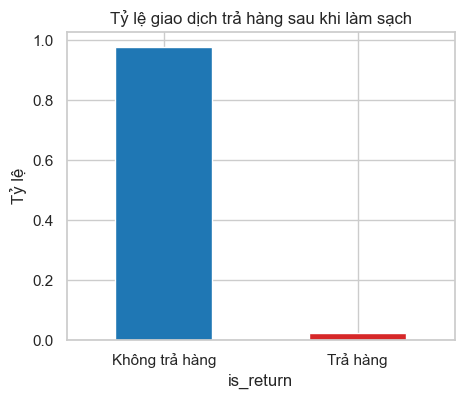

In [4]:
# 3 biểu đồ minh họa trước/sau làm sạch
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: Phân phối UnitPrice trước vs sau
sns.histplot(raw_df["UnitPrice"], bins=50, ax=axes[0], color="tab:blue", kde=False)
axes[0].set_title("Phân phối UnitPrice - Trước khi làm sạch")
axes[0].set_xlim(0, raw_df["UnitPrice"].quantile(0.99))

sns.histplot(clean_df["UnitPrice"], bins=50, ax=axes[1], color="tab:green", kde=False)
axes[1].set_title("Phân phối UnitPrice - Sau khi làm sạch")
axes[1].set_xlim(0, clean_df["UnitPrice"].quantile(0.99))

plt.tight_layout()
plt.show()

# Biểu đồ 2: Boxplot Quantity trước vs sau
plt.figure(figsize=(8, 5))
qty_compare = pd.DataFrame(
    {
        "Quantity": pd.concat([raw_df["Quantity"], clean_df["Quantity"]], ignore_index=True),
        "Trạng thái": ["Trước"] * len(raw_df) + ["Sau"] * len(clean_df),
    }
)
sns.boxplot(data=qty_compare, x="Trạng thái", y="Quantity")
plt.title("So sánh phân phối Quantity trước và sau làm sạch")
plt.ylim(0, qty_compare["Quantity"].quantile(0.99))
plt.show()

# Biểu đồ 3: Tỷ lệ giao dịch trả hàng vs không trả hàng
if "is_return" in clean_df.columns:
    plt.figure(figsize=(5, 4))
    clean_df["is_return"].value_counts(normalize=True).rename({0: "Không trả hàng", 1: "Trả hàng"}).plot(
        kind="bar", color=["tab:blue", "tab:red"]
    )
    plt.ylabel("Tỷ lệ")
    plt.title("Tỷ lệ giao dịch trả hàng sau khi làm sạch")
    plt.xticks(rotation=0)
    plt.show()


In [5]:
import os

print("Đang tính toán đặc trưng RFM từ dữ liệu đã làm sạch...")

# Đảm bảo cột thời gian đúng định dạng
clean_df['InvoiceDate'] = pd.to_datetime(clean_df['InvoiceDate'])

# Tính tổng tiền cho từng dòng
clean_df['TotalPrice'] = clean_df['Quantity'] * clean_df['UnitPrice']

# Tính RFM (Recency, Frequency, Monetary)
snapshot_date = clean_df['InvoiceDate'].max() + pd.Timedelta(days=1)

features_df = clean_df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'TotalPrice': 'sum',                                     # Monetary
    'is_return': 'max'                                       # Có trả hàng hay không
}).rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'TotalPrice': 'Monetary'})

# BẮT BUỘC TẠO THƯ MỤC NẾU CHƯA CÓ VÀ LƯU FILE
os.makedirs('../data/processed', exist_ok=True)
output_path = '../data/processed/features.parquet'

features_df.to_parquet(output_path)

print(f"🎉 CHÚC MỪNG! ĐÃ LƯU FILE THÀNH CÔNG TẠI: {output_path}")
print(f"Kích thước bộ dữ liệu để huấn luyện: {features_df.shape}")

Đang tính toán đặc trưng RFM từ dữ liệu đã làm sạch...
🎉 CHÚC MỪNG! ĐÃ LƯU FILE THÀNH CÔNG TẠI: ../data/processed/features.parquet
Kích thước bộ dữ liệu để huấn luyện: (4371, 4)


### Giải thích các biểu đồ

- **Biểu đồ phân phối UnitPrice trước/sau làm sạch**: Cho thấy các giá trị giá bán bất thường (rất lớn hoặc bằng 0) đã được xử lý bằng cách loại bỏ hoặc winsorize theo quantile, giúp phân phối giá trở nên "gọn" hơn và ổn định cho việc huấn luyện mô hình.
- **Boxplot Quantity trước/sau làm sạch**: So sánh mức độ phân tán và outlier của số lượng sản phẩm. Sau làm sạch, các outlier cực trị được cắt/bóp (clip) nên hộp boxplot thu hẹp lại, giảm ảnh hưởng của các giao dịch bất thường.
- **Biểu đồ tỷ lệ giao dịch trả hàng**: Thể hiện tỷ lệ các giao dịch được gán nhãn `is_return = 1` so với `is_return = 0`. Đây là cái nhìn tổng quan về mức độ mất cân bằng lớp, rất quan trọng cho bài toán phân lớp và quyết định chiến lược xử lý mất cân bằng (SMOTE, class_weight, v.v.).
